# Simple FEV Chronos2 Comparison

Goal: run one real FEV task in two ways and compare outputs:

1. Window-by-window (current approach)
2. Batched across all windows (single `predict` call), using `VariableLengthTorchTrainingDataset` for the fit step

In [1]:
import time
from collections.abc import Sequence

import fev
import numpy as np

import darts.models as darts_models
import datasets
from darts import TimeSeries
from darts.models.forecasting.foundation_model import FoundationModel
from darts.utils.data.torch_datasets.training_dataset import (
    VariableLengthTorchTrainingDataset,
)
from darts.utils.likelihood_models import QuantileRegression

datasets.disable_progress_bars()

# Simple defaults (no argparse)
BENCHMARK_PATH = "fev_tasks_mini.yaml"
TASK_INDEX = 18  # small default task for quick iteration
MODEL_NAME = "Chronos2Model"
HUB_MODEL = "autogluon/chronos-2-small"
MAX_INPUT_CHUNK_LENGTH = 32
BATCH_SIZE = 64
RANDOM_STATE = 42

# Numerical comparison tolerance for floating-point inference differences.
COMPARE_ATOL = 1e-4
COMPARE_RTOL = 1e-4

c:\projects\darts\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def _to_list(ts_or_list):
    if isinstance(ts_or_list, TimeSeries):
        return [ts_or_list]
    if isinstance(ts_or_list, Sequence):
        return list(ts_or_list)
    raise TypeError(f"Unsupported prediction type: {type(ts_or_list)}")


def _values_equal(
    ts_a: TimeSeries, ts_b: TimeSeries, atol=COMPARE_ATOL, rtol=COMPARE_RTOL
) -> bool:
    va = ts_a.values(copy=False)
    vb = ts_b.values(copy=False)
    return va.shape == vb.shape and np.allclose(va, vb, atol=atol, rtol=rtol)


def _max_abs_diff(ts_a: TimeSeries, ts_b: TimeSeries) -> float:
    va = ts_a.values(copy=False)
    vb = ts_b.values(copy=False)
    if va.shape != vb.shape:
        return np.inf
    return float(np.max(np.abs(va - vb)))


def _astype_float32_list(ts_list):
    if ts_list is None:
        return None
    return [ts.astype(np.float32) if ts is not None else None for ts in ts_list]


def _get_window_payloads(task: fev.Task):
    payloads = []
    for window_idx, window in enumerate(task.iter_windows(), start=1):
        series, past_covariates, future_covariates = fev.convert_input_data(
            window,
            adapter="darts",
            as_univariate=False,
        )

        # Keep dtype consistent for MPS/torch and numeric comparisons.
        series = _astype_float32_list(series)
        past_covariates = _astype_float32_list(past_covariates)
        future_covariates = _astype_float32_list(future_covariates)

        payloads.append({
            "window_idx": window_idx,
            "series": series,
            "past_covariates": past_covariates,
            "future_covariates": future_covariates,
        })
    return payloads

In [3]:
benchmark = fev.Benchmark.from_yaml(BENCHMARK_PATH)
task = benchmark.tasks[TASK_INDEX]

print(f"Task index: {TASK_INDEX}")
print(f"dataset_config: {task.dataset_config}")
print(f"horizon: {task.horizon}")
print(f"num_windows: {task.num_windows}")
print(f"random_state: {RANDOM_STATE}")

model_cls: type[FoundationModel] = getattr(darts_models, MODEL_NAME)
common_model_kwargs = {
    "output_chunk_length": task.horizon,
    "hub_model_name": HUB_MODEL,
    "likelihood": QuantileRegression(task.quantile_levels),
    "batch_size": BATCH_SIZE,
    "random_state": RANDOM_STATE,
}

payloads = _get_window_payloads(task)

# Build an index of all series across all windows for robust comparison later.
series_records = []
for window_idx, payload in enumerate(payloads, start=1):
    for series_idx, series in enumerate(payload["series"], start=1):
        series_records.append({
            "window_idx": window_idx,
            "series_idx": series_idx,
            "series": series,
            "past_covariates": payload["past_covariates"][series_idx - 1]
            if payload["past_covariates"] is not None
            else None,
            "future_covariates": payload["future_covariates"][series_idx - 1]
            if payload["future_covariates"] is not None
            else None,
        })

# -----------------------------------------------------------------------------
# 1) CURRENT SOLUTION: process window-by-window
# -----------------------------------------------------------------------------
seq_results = {}  # (window_idx, series_idx) -> prediction TimeSeries
window_input_chunk_lengths = []
seq_inference_time = 0.0

for window_idx, payload in enumerate(payloads, start=1):
    min_series_length = min(len(s) for s in payload["series"])
    input_chunk_length = min(min_series_length - task.horizon, MAX_INPUT_CHUNK_LENGTH)
    if input_chunk_length <= 0:
        raise ValueError(
            f"Window {window_idx} has non-positive input_chunk_length={input_chunk_length}"
        )

    window_input_chunk_lengths.append(input_chunk_length)
    model = model_cls(input_chunk_length=input_chunk_length, **common_model_kwargs)

    series_kwargs = {
        "series": payload["series"],
        "past_covariates": payload["past_covariates"],
        "future_covariates": payload["future_covariates"],
    }
    if not model.supports_past_covariates:
        series_kwargs.pop("past_covariates")
    if not model.supports_future_covariates:
        series_kwargs.pop("future_covariates")

    model.fit(**series_kwargs)

    start = time.monotonic()
    preds = _to_list(
        model.predict(
            n=task.horizon,
            predict_likelihood_parameters=True,
            **series_kwargs,
        )
    )
    seq_inference_time += time.monotonic() - start

    for series_idx, pred in enumerate(preds, start=1):
        seq_results[(window_idx, series_idx)] = pred

print("\nStep 1 completed (window-by-window).")
print(
    f"Unique per-window input_chunk_length values: {sorted(set(window_input_chunk_lengths))}"
)

Task index: 18
dataset_config: us_consumption_1Y
horizon: 5
num_windows: 10
random_state: 42


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\projects\darts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\projects\darts\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 54.39it/s]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\projects\darts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\projects\darts\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 64.75it/s]


...

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 28.58it/s]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\projects\darts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\projects\darts\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 37.12it/s]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\projects\darts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\projects\darts\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 49.36it/s]

Step 1 completed (window-by-window).
Unique per-window input_chunk_length values: [9, 14, 19, 24, 29, 32]


In [4]:
# -----------------------------------------------------------------------------
# 2) FIXED-CONTEXT WINDOW-BY-WINDOW: input_chunk_length=32 for each window
#    - manual NaN pre-padding before fit() (no VariableLengthTorchTrainingDataset)
#    - isolates context-length effects from batching effects
# -----------------------------------------------------------------------------
fixed_icl = MAX_INPUT_CHUNK_LENGTH
fixed_window_results = {}  # (window_idx, series_idx) -> prediction TimeSeries
fixed_window_inference_time = 0.0

min_fit_len = (
    fixed_icl + task.horizon
)  # minimum length SequentialTorchTrainingDataset requires


def _left_pad_series_with_nan(ts: TimeSeries, min_len: int) -> TimeSeries:
    """Left-pad `ts` with NaN rows until it has at least `min_len` time steps."""
    pad_len = min_len - len(ts)
    if pad_len <= 0:
        return ts
    pad_values = np.full((pad_len, ts.n_components, ts.n_samples), np.nan, dtype=float)
    return ts.prepend_values(pad_values)


def _left_pad_list_with_nan(ts_list, min_len: int):
    if ts_list is None:
        return None
    return [
        _left_pad_series_with_nan(ts, min_len) if ts is not None else None
        for ts in ts_list
    ]


for window_idx, payload in enumerate(payloads, start=1):
    fixed_window_model = model_cls(input_chunk_length=fixed_icl, **common_model_kwargs)

    # Manually pad short series so fit() can use the standard SequentialTorchTrainingDataset.
    fit_series = _left_pad_list_with_nan(payload["series"], min_fit_len)
    fit_past_cov = _left_pad_list_with_nan(payload["past_covariates"], min_fit_len)
    fit_future_cov = _left_pad_list_with_nan(payload["future_covariates"], min_fit_len)

    fit_kwargs = {"series": fit_series}
    if (
        fixed_window_model.supports_past_covariates
        and fit_past_cov is not None
        and all(c is not None for c in fit_past_cov)
    ):
        fit_kwargs["past_covariates"] = fit_past_cov
    if (
        fixed_window_model.supports_future_covariates
        and fit_future_cov is not None
        and all(c is not None for c in fit_future_cov)
    ):
        fit_kwargs["future_covariates"] = fit_future_cov

    fixed_window_model.fit(**fit_kwargs)

    # FoundationModel._build_inference_dataset auto-pads short series with NaN —
    # no manual pre-padding needed before predict().
    fixed_window_predict_kwargs = {"series": payload["series"]}
    if (
        fixed_window_model.supports_past_covariates
        and payload["past_covariates"] is not None
        and all(c is not None for c in payload["past_covariates"])
    ):
        fixed_window_predict_kwargs["past_covariates"] = payload["past_covariates"]
    if (
        fixed_window_model.supports_future_covariates
        and payload["future_covariates"] is not None
        and all(c is not None for c in payload["future_covariates"])
    ):
        fixed_window_predict_kwargs["future_covariates"] = payload["future_covariates"]

    start = time.monotonic()
    fixed_window_preds = _to_list(
        fixed_window_model.predict(
            n=task.horizon,
            predict_likelihood_parameters=True,
            **fixed_window_predict_kwargs,
        )
    )
    fixed_window_inference_time += time.monotonic() - start

    for series_idx, pred in enumerate(fixed_window_preds, start=1):
        fixed_window_results[(window_idx, series_idx)] = pred

print(
    "\nStep 2 completed (window-by-window, fixed input_chunk_length=32, manual NaN padding)."
)
print(f"Fixed input_chunk_length used: {fixed_icl}")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\projects\darts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\projects\darts\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 23.65it/s]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\projects\darts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\projects\darts\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 30.93it/s]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\projects\darts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\projects\darts\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


...

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 26.49it/s]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\projects\darts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\projects\darts\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 52.19it/s]


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\projects\darts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\projects\darts\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 57.06it/s]

Step 2 completed (window-by-window, fixed input_chunk_length=32, manual NaN padding).
Fixed input_chunk_length used: 32


In [5]:
# -----------------------------------------------------------------------------
# 3) EFFICIENT SOLUTION: single-pass processing with fixed input_chunk_length=32
#    - one model fit + one predict across all windows/series
# -----------------------------------------------------------------------------
all_series = [r["series"] for r in series_records]
all_past_cov = [r["past_covariates"] for r in series_records]
all_future_cov = [r["future_covariates"] for r in series_records]

single_pass_model = model_cls(input_chunk_length=fixed_icl, **common_model_kwargs)

single_pass_train_ds = VariableLengthTorchTrainingDataset(
    series=all_series,
    input_chunk_length=fixed_icl,
    output_chunk_length=task.horizon,
    max_samples_per_ts=1,
    use_static_covariates=False,
)
single_pass_model.fit_from_dataset(single_pass_train_ds)

# FoundationModel._build_inference_dataset auto-pads short series with NaN —
# no manual pre-padding needed before predict().
predict_kwargs = {"series": all_series}
if (
    single_pass_model.supports_past_covariates
    and all_past_cov is not None
    and all(cov is not None for cov in all_past_cov)
):
    predict_kwargs["past_covariates"] = all_past_cov
if (
    single_pass_model.supports_future_covariates
    and all_future_cov is not None
    and all(cov is not None for cov in all_future_cov)
):
    predict_kwargs["future_covariates"] = all_future_cov

start = time.monotonic()
single_pass_preds = _to_list(
    single_pass_model.predict(
        n=task.horizon,
        predict_likelihood_parameters=True,
        **predict_kwargs,
    )
)
single_pass_inference_time = time.monotonic() - start

single_pass_results = {}  # (window_idx, series_idx) -> prediction TimeSeries
for record, pred in zip(series_records, single_pass_preds):
    single_pass_results[(record["window_idx"], record["series_idx"])] = pred

print("Step 3 completed (single-pass fixed input_chunk_length).")
print(f"Total series processed in one pass: {len(all_series)}")

# -----------------------------------------------------------------------------
# Compare all three paths
# -----------------------------------------------------------------------------
assert (
    set(seq_results.keys())
    == set(fixed_window_results.keys())
    == set(single_pass_results.keys())
)


def _collect_mismatches(lhs_results, rhs_results):
    out = []
    for key in sorted(lhs_results.keys()):
        if not _values_equal(lhs_results[key], rhs_results[key]):
            out.append((key, _max_abs_diff(lhs_results[key], rhs_results[key])))
    return sorted(out, key=lambda x: x[1], reverse=True)


def _print_mismatch_summary(title: str, mismatch_list):
    print(f"\n{title}")
    if not mismatch_list:
        print("  ✓ No mismatches within tolerance")
        return
    for key, diff in mismatch_list[:5]:
        print(f"  key={key}: max_abs_diff={diff:.6g}")
    print(f"  total mismatches: {len(mismatch_list)}")


adaptive_vs_fixed_window_mismatches = _collect_mismatches(
    seq_results, fixed_window_results
)
batching_mismatches = _collect_mismatches(fixed_window_results, single_pass_results)
adaptive_vs_single_pass_mismatches = _collect_mismatches(
    seq_results, single_pass_results
)

_print_mismatch_summary(
    "Step 1 adaptive ICL vs Step 2 fixed-32 window-by-window:",
    adaptive_vs_fixed_window_mismatches,
)
_print_mismatch_summary(
    "Step 2 fixed-32 window-by-window vs Step 3 fixed-32 single-pass:",
    batching_mismatches,
)
_print_mismatch_summary(
    "Step 1 adaptive ICL vs Step 3 fixed-32 single-pass:",
    adaptive_vs_single_pass_mismatches,
)

seq_speedup = seq_inference_time / max(single_pass_inference_time, 1e-12)
fixed_window_speedup = fixed_window_inference_time / max(
    single_pass_inference_time, 1e-12
)
print(f"\nTolerance: atol={COMPARE_ATOL}, rtol={COMPARE_RTOL}")
print(f"Total windows: {len(payloads)}")
print(f"Total series across all windows: {len(series_records)}")
print(f"Step 1 inference time (adaptive window-by-window): {seq_inference_time:.3f}s")
print(
    f"Step 2 inference time (fixed-32 window-by-window): {fixed_window_inference_time:.3f}s"
)
print(
    f"Step 3 inference time (fixed-32 single-pass): {single_pass_inference_time:.3f}s"
)
print(f"Speedup step1/step3: {seq_speedup:.3f}x")
print(f"Speedup step2/step3: {fixed_window_speedup:.3f}x")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Dataset output has a different data type than the dataset the model was trained on; current data type: float64, expected data type: float32. This might cause downstream issues when running the model. If so, make sure all your input data have the expected data type (TimeSeries, static covariates, ...).
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
c:\projects\darts\.venv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\projects\darts\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predicting DataLoader 0: 100%|██████████| 5/5 [00:00<00:00, 29.14it/s]
Step 3 completed (single-pass fixed input_chunk_length).
Total series processed in one pass: 310

Step 1 adaptive ICL vs Step 2 fixed-32 window-by-window:
  key=(4, 20): max_abs_diff=3.82124e+06
  key=(1, 20): max_abs_diff=2.34697e+06
  key=(3, 20): max_abs_diff=2.2806e+06
  key=(2, 20): max_abs_diff=2.256e+06
  key=(5, 20): max_abs_diff=1.99896e+06
  total mismatches: 155

Step 2 fixed-32 window-by-window vs Step 3 fixed-32 single-pass:
  ✓ No mismatches within tolerance

Step 1 adaptive ICL vs Step 3 fixed-32 single-pass:
  key=(4, 20): max_abs_diff=3.82124e+06
  key=(1, 20): max_abs_diff=2.34698e+06
  key=(3, 20): max_abs_diff=2.2806e+06
  key=(2, 20): max_abs_diff=2.256e+06
  key=(5, 20): max_abs_diff=1.99896e+06
  total mismatches: 155

Tolerance: atol=0.0001, rtol=0.0001
Total windows: 10
Total series across all windows: 310
Step 1 inference time (adaptive window-by-window): 0.394s
Step 2 inference time (fixed

In [6]:
{
    "fixed_input_chunk_length": fixed_icl,
    "unique_step1_input_chunk_lengths": sorted(set(window_input_chunk_lengths)),
    "total_windows": len(payloads),
    "total_series": len(series_records),
    "single_pass_dataset_samples": len(single_pass_train_ds),
    "adaptive_vs_fixed_window_mismatches": len(adaptive_vs_fixed_window_mismatches),
    "batching_mismatches": len(batching_mismatches),
    "adaptive_vs_single_pass_mismatches": len(adaptive_vs_single_pass_mismatches),
}

{'fixed_input_chunk_length': 32,
 'unique_step1_input_chunk_lengths': [9, 14, 19, 24, 29, 32],
 'total_windows': 10,
 'total_series': 310,
 'single_pass_dataset_samples': 310,
 'adaptive_vs_fixed_window_mismatches': 155,
 'batching_mismatches': 0,
 'adaptive_vs_single_pass_mismatches': 155}

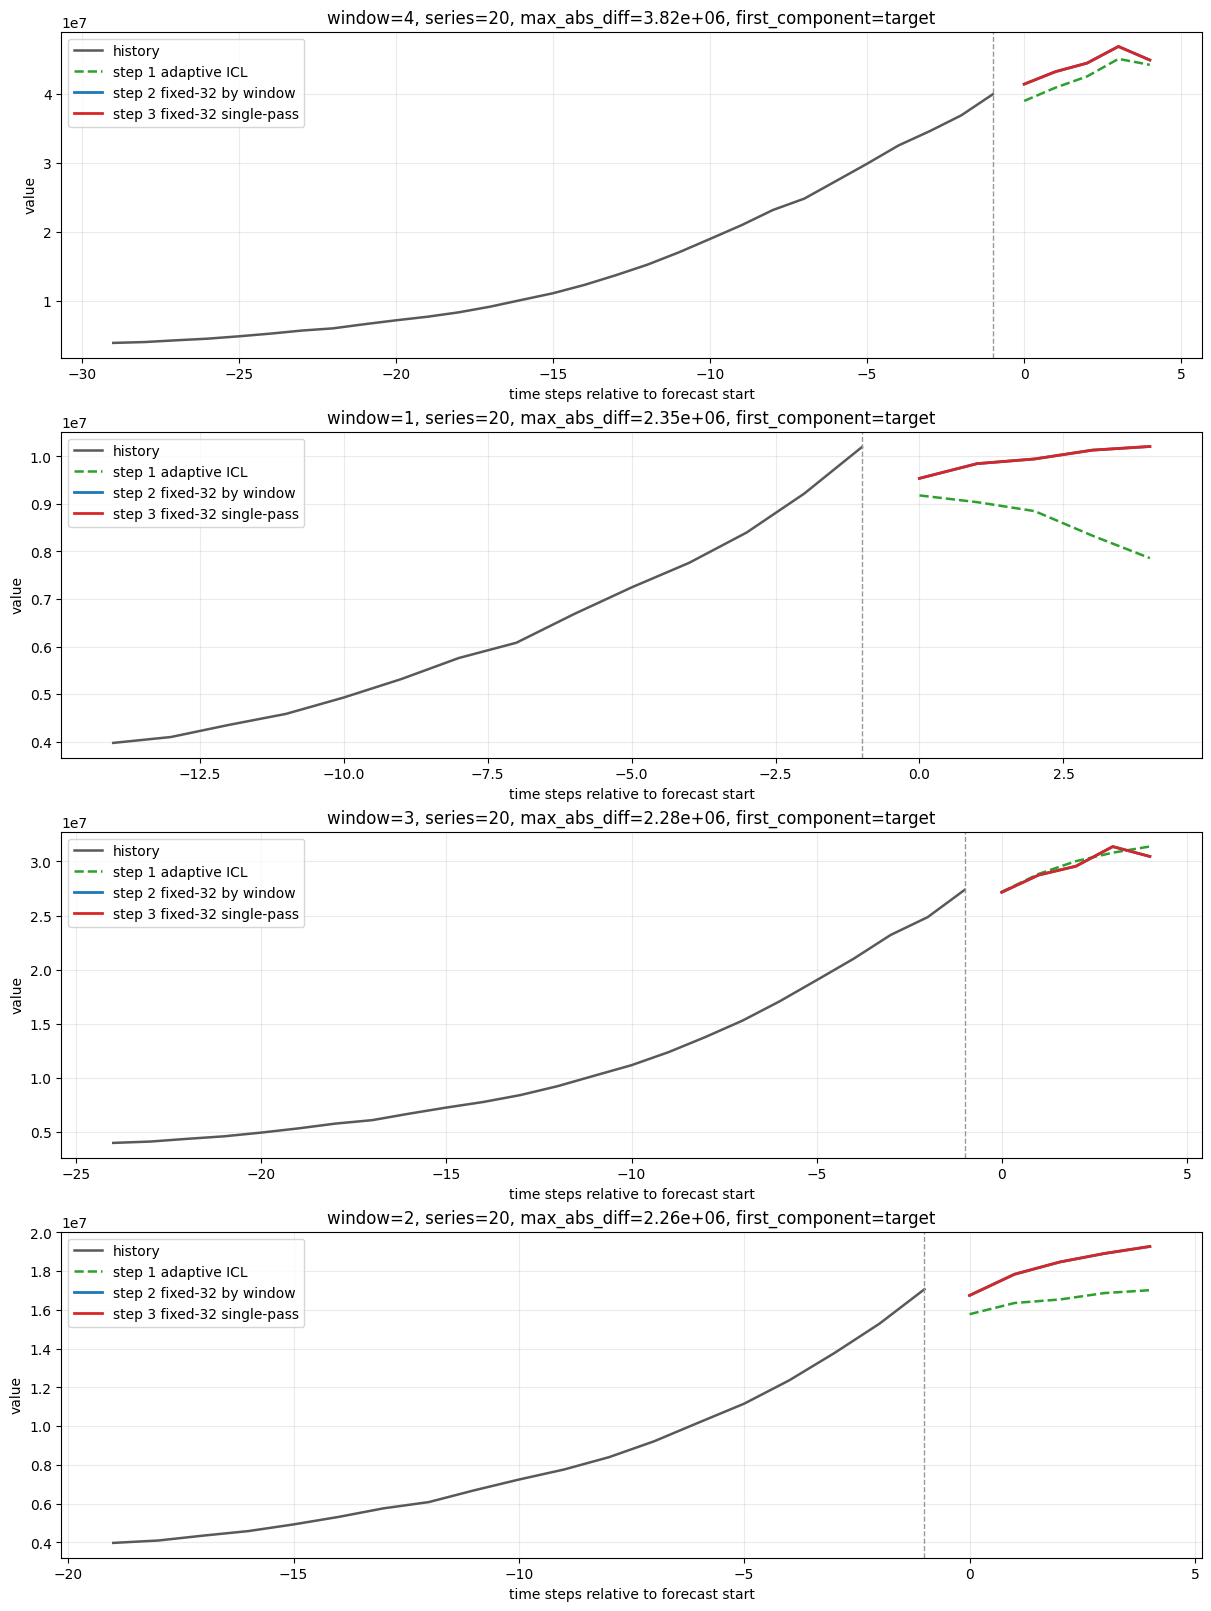

Plotted the largest mismatch cases for adaptive vs fixed-32 window-by-window.
Interpretation: gray=history, green dashed=adaptive baseline, blue=fixed-32 by window, red=fixed-32 single-pass.


In [ ]:
import matplotlib.pyplot as plt


def _first_component_values(ts: TimeSeries) -> np.ndarray:
    values = ts.values(copy=False)
    if values.ndim == 1:
        return values
    return values[:, 0]


def _component_label(ts: TimeSeries) -> str:
    components = list(ts.components)
    return str(components[0]) if components else "component_0"


record_lookup = {
    (record["window_idx"], record["series_idx"]): record for record in series_records
}

plot_mismatches = (
    batching_mismatches if batching_mismatches else adaptive_vs_fixed_window_mismatches
)
plot_mismatch_title = (
    "fixed-32 window-by-window vs fixed-32 single-pass"
    if batching_mismatches
    else "adaptive vs fixed-32 window-by-window"
)

if not plot_mismatches:
    print("No mismatches to plot.")
else:
    num_plots = min(4, len(plot_mismatches))
    fig, axes = plt.subplots(
        num_plots, 1, figsize=(12, 4.0 * num_plots), constrained_layout=True
    )
    if num_plots == 1:
        axes = [axes]

    for axis, (key, diff) in zip(axes, plot_mismatches[:num_plots]):
        record = record_lookup[key]
        history = record["series"]
        adaptive_pred = seq_results[key]
        fixed_window_pred = fixed_window_results[key]
        single_pass_pred = single_pass_results[key]

        history_vals = _first_component_values(history)
        adaptive_vals = _first_component_values(adaptive_pred)
        fixed_window_vals = _first_component_values(fixed_window_pred)
        single_pass_vals = _first_component_values(single_pass_pred)

        history_len_to_plot = min(len(history_vals), 64)
        history_slice = history_vals[-history_len_to_plot:]

        history_x = np.arange(-history_len_to_plot, 0)
        pred_x = np.arange(0, len(adaptive_vals))

        axis.plot(
            history_x, history_slice, label="history", color="0.35", linewidth=1.8
        )
        axis.plot(
            pred_x,
            adaptive_vals,
            label="step 1 adaptive ICL",
            color="#2ca02c",
            linewidth=1.8,
            linestyle="--",
        )
        axis.plot(
            pred_x,
            fixed_window_vals,
            label="step 2 fixed-32 by window",
            color="#1f77b4",
            linewidth=2,
        )
        axis.plot(
            pred_x,
            single_pass_vals,
            label="step 3 fixed-32 single-pass",
            color="#d62728",
            linewidth=2,
        )
        axis.axvline(-1, color="0.6", linestyle="--", linewidth=1)
        axis.set_title(
            f"window={key[0]}, series={key[1]}, max_abs_diff={diff:.3g}, first_component={_component_label(history)}"
        )
        axis.set_xlabel("time steps relative to forecast start")
        axis.set_ylabel("value")
        axis.legend(loc="best")
        axis.grid(alpha=0.25)

    plt.show()

    print(f"Plotted the largest mismatch cases for {plot_mismatch_title}.")
    print(
        "Interpretation: gray=history, green dashed=adaptive baseline, blue=fixed-32 window, red=fixed-32 single-pass"
    )

In [8]:
top_plot_mismatches = plot_mismatches[:5]
summary_rows = []
for key, diff in top_plot_mismatches:
    record = record_lookup[key]
    history = record["series"]
    adaptive_pred = seq_results[key]
    fixed_window_pred = fixed_window_results[key]
    single_pass_pred = single_pass_results[key]

    history_vals = _first_component_values(history)
    adaptive_vals = _first_component_values(adaptive_pred)
    fixed_window_vals = _first_component_values(fixed_window_pred)
    single_pass_vals = _first_component_values(single_pass_pred)

    batching_scale = max(np.max(np.abs(fixed_window_vals)), 1e-12)
    history_scale = max(np.max(np.abs(history_vals)), 1e-12)
    summary_rows.append({
        "key": key,
        "max_abs_diff_step2_vs_step3": float(diff),
        "max_rel_diff_step2_vs_step3": float(diff / batching_scale),
        "max_rel_diff_vs_history": float(diff / history_scale),
        "step1_last": float(adaptive_vals[-1]),
        "step2_last": float(fixed_window_vals[-1]),
        "step3_last": float(single_pass_vals[-1]),
        "history_last": float(history_vals[-1]),
    })

summary_rows

[{'key': (4, 20),
  'max_abs_diff_step2_vs_step3': 3821236.0,
  'max_rel_diff_step2_vs_step3': 0.08151892918603608,
  'max_rel_diff_vs_history': 0.09562616050243378,
  'step1_last': 44223000.0,
  'step2_last': 44914440.0,
  'step3_last': 44914440.0,
  'history_last': 39960152.0},
 {'key': (1, 20),
  'max_abs_diff_step2_vs_step3': 2346971.0,
  'max_rel_diff_step2_vs_step3': 0.22992680850396818,
  'max_rel_diff_vs_history': 0.23021043837070465,
  'step1_last': 7860499.0,
  'step2_last': 10207470.0,
  'step3_last': 10207474.0,
  'history_last': 10194894.0},
 {'key': (3, 20),
  'max_abs_diff_step2_vs_step3': 2280596.0,
  'max_rel_diff_step2_vs_step3': 0.0726810355641175,
  'max_rel_diff_vs_history': 0.08329649269580841,
  'step1_last': 31387072.0,
  'step2_last': 30465892.0,
  'step3_last': 30465900.0,
  'history_last': 27379256.0},
 {'key': (2, 20),
  'max_abs_diff_step2_vs_step3': 2256000.0,
  'max_rel_diff_step2_vs_step3': 0.1170509389498414,
  'max_rel_diff_vs_history': 0.1321846991777